# Memory Footprint Analysis on NVIDIA Jetson: Transformer vs. SSM Models

This notebook measures and visualizes the **GPU memory footprint** of six language model architectures across increasing sequence lengths during the **prefill phase**, profiled on an **NVIDIA Jetson** platform (8 GB unified memory):

| Model | Type | Size |
|-------|------|------|
| Qwen2.5-0.5B-Instruct | Transformer | ~0.5B |
| Llama 3.2 | Transformer | ~1B |
| Mamba-790m | SSM (Mamba-1) | ~790M |
| Mamba2-780m | SSM (Mamba-2) | ~780M |
| Falcon-H1 0.5B | Hybrid SSM | ~0.5B |
| Zamba2 | Hybrid SSM | ~2.7B |

Memory is decomposed into three stacked components:
- **Model Size** — static parameter memory (constant across sequence lengths)
- **Activation Memory** — intermediate tensors during the forward pass
- **KV Cache** — key-value cache for attention layers (zero for pure SSMs)

The 8 GB memory budget is significantly tighter than a desktop GPU, which drives shorter max-sequence-length limits for transformer-based models. Results are saved to `memory_footprint_jetson_ispass.png` for use as a paper figure.

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys


## Sequence Length Configuration

Define the per-model sequence length ranges used for profiling. Ranges are shorter than on a desktop GPU because the Jetson's 8 GB unified memory imposes tighter constraints — particularly for transformer models whose KV cache grows with sequence length.

In [2]:
# Define sequence lengths to test
mamba_790m_seq_lengths = [256, 512, 1024, 2048, 4096, 8192, 16384, 24576, 32768]
# mamba_1_4b_seq_lengths = [256, 512, 1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344, 65536, 73728, 81920, 90112, 98304, 106496, 114688, 122880, 131072, 139264, 147456, 155648, 200000]
mamba2_780m_seq_lengths = [256, 512, 1024, 2048, 4096, 8192, 16384, 24576, 32768]
qwen_seq_lengths = [256, 512, 1024, 2048, 4096, 8192, 16384]
# qwen_1_5b_seq_lengths = [256, 512, 1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344]
zamba2_seq_lengths = [256, 512, 1024, 2048, 4096, 8192]
llama_3_2_seq_lengths = [256, 512, 1024, 2048, 4096, 8192]
falcon_h1_seq_lengths = [256, 512, 1024, 2048, 4096, 8192, 16384, 24576, 32768]
# phi3_seq_lengths = [256, 512, 1024, 2048, 4096]
# qwen_seq_lengths = [64, 256, 1024, 8192, 32768]
# mamba_seq_lengths = [64, 256, 1024, 8192, 32768, 65536, 131072]

## Helper Functions

Utility functions used throughout the notebook:
- `get_model_data` — extracts memory breakdown for a model at each requested sequence length; fills zeros for missing entries (OOM)
- `create_arrays` — converts the per-sequence-length dict into flat arrays

In [3]:
# Prepare data for plotting - function to get model data for specific sequence lengths
def get_model_data(df, seq_lengths):
    data = {}
    for seq_len in seq_lengths:
        row = df[df['seq_len'] == seq_len]
        if not row.empty:
            data[seq_len] = {
                'model_size': row['model_size_mb'].values[0],
                'activation': row['activation_memory_mb'].values[0],
                'kv_cache': row['kv_cache_mb'].values[0],
                'reserved': row['reserved_memory_mb'].values[0],
                'total': row['total_memory_mb'].values[0]
            }
        else:
            data[seq_len] = {'model_size': 0, 'activation': 0, 'kv_cache': 0, 'reserved': 0, 'total': 0}
    return data

# Function to create arrays for plotting
def create_arrays(model_data, seq_lengths):
    return {
        'model_sizes': [model_data[seq_len]['model_size'] for seq_len in seq_lengths],
        'activations': [model_data[seq_len]['activation'] for seq_len in seq_lengths],
        'kv_caches': [model_data[seq_len]['kv_cache'] for seq_len in seq_lengths],
        'reserved': [model_data[seq_len]['reserved'] for seq_len in seq_lengths],
        'totals': [model_data[seq_len]['total'] for seq_len in seq_lengths]
    }

# Function to plot reserved memory lines for valid data points
def plot_reserved_memory(x_positions, model_arrays, seq_lengths, bar_width_offset, color, label):
    x_vals = []
    reserved_vals = []
    for i, reserved in enumerate(model_arrays['reserved']):
        if reserved > 0:  # Only include points with actual data
            x_vals.append(x[i] + bar_width_offset)
            reserved_vals.append(reserved)
    
    if x_vals:  # Only plot if there are valid data points
        plt.plot(x_vals, reserved_vals, color=color, linestyle='--', marker='o', linewidth=2, label=label)

## Load Data

Load the pre-collected memory profiling results from `memory_footprints_jetson.csv`. Each row records the memory breakdown for one `(model, sequence_length)` combination measured on the Jetson platform.

In [5]:
# Load the CSV file
csv_path = 'memory_footprints_jetson.csv'
df = pd.read_csv(csv_path)

# Create two dataframes for the two models
qwen_df = df[df['model_name'] == 'qwen25-instruct'].sort_values('seq_len')
mamba_df = df[df['model_name'] == 'mamba-790m'].sort_values('seq_len')
# qwen_1_5b_df = df[df['model_name'] == 'qwen25-1.5b-instruct'].sort_values('seq_len')
# mamba_1_4b_df = df[df['model_name'] == 'mamba-1.4b'].sort_values('seq_len')
mamba2_df = df[df['model_name'] == 'mamba2-780m'].sort_values('seq_len')
zamba2_df = df[df['model_name'] == 'zamba2'].sort_values('seq_len')
# phi_df = df[df['model_name'] == 'phi3'].sort_values('seq_len')
llama3_2_df = df[df['model_name'] == 'llama3_2'].sort_values('seq_len')
falcon_h1_df = df[df['model_name'] == 'falcon-h1-0.5b'].sort_values('seq_len')

print("Qwen data:")
print(qwen_df)
print("\nMamba data:")
print(mamba_df)
print("\nQwen 1.5B data:")
# print(qwen_1_5b_df)
# print("\nMamba 1.4B data:")
# print(mamba_1_4b_df)
# print("\nZamba2 data:")
print(zamba2_df)
# print("\nPhi data:")
# print(phi_df)
print("\nLlama 3.2 data:")
print(llama3_2_df)
print("\nMamba2 data:")
print(mamba2_df)
print("\nFalcon H1 data:")
print(falcon_h1_df)

Qwen data:
        model_name                model_config  seq_len  batch_size  \
0  qwen25-instruct  Qwen/Qwen2.5-0.5B-Instruct      256           1   
1  qwen25-instruct  Qwen/Qwen2.5-0.5B-Instruct      512           1   
2  qwen25-instruct  Qwen/Qwen2.5-0.5B-Instruct     1024           1   
3  qwen25-instruct  Qwen/Qwen2.5-0.5B-Instruct     2048           1   
4  qwen25-instruct  Qwen/Qwen2.5-0.5B-Instruct     4096           1   
5  qwen25-instruct  Qwen/Qwen2.5-0.5B-Instruct     8192           1   
6  qwen25-instruct  Qwen/Qwen2.5-0.5B-Instruct    16384           1   

   model_size_mb  activation_memory_mb  kv_cache_mb  reserved_memory_mb  \
0         942.29                 82.78          3.0              1222.0   
1         942.29                157.41          6.0              1228.0   
2         942.29                306.67         12.0              1526.0   
3         942.29                605.69         24.0              1834.0   
4         942.29               1203.22       

## Visualization — Annotated Bar Chart

Stacked grouped bar chart comparing all six models across the shared set of sequence lengths. Each group of bars represents one sequence length; within each group the bars are ordered **Llama → Qwen → Mamba → Mamba2 → Falcon-H1 → Zamba2**. The dashed red line marks the 8 GB Jetson memory limit.

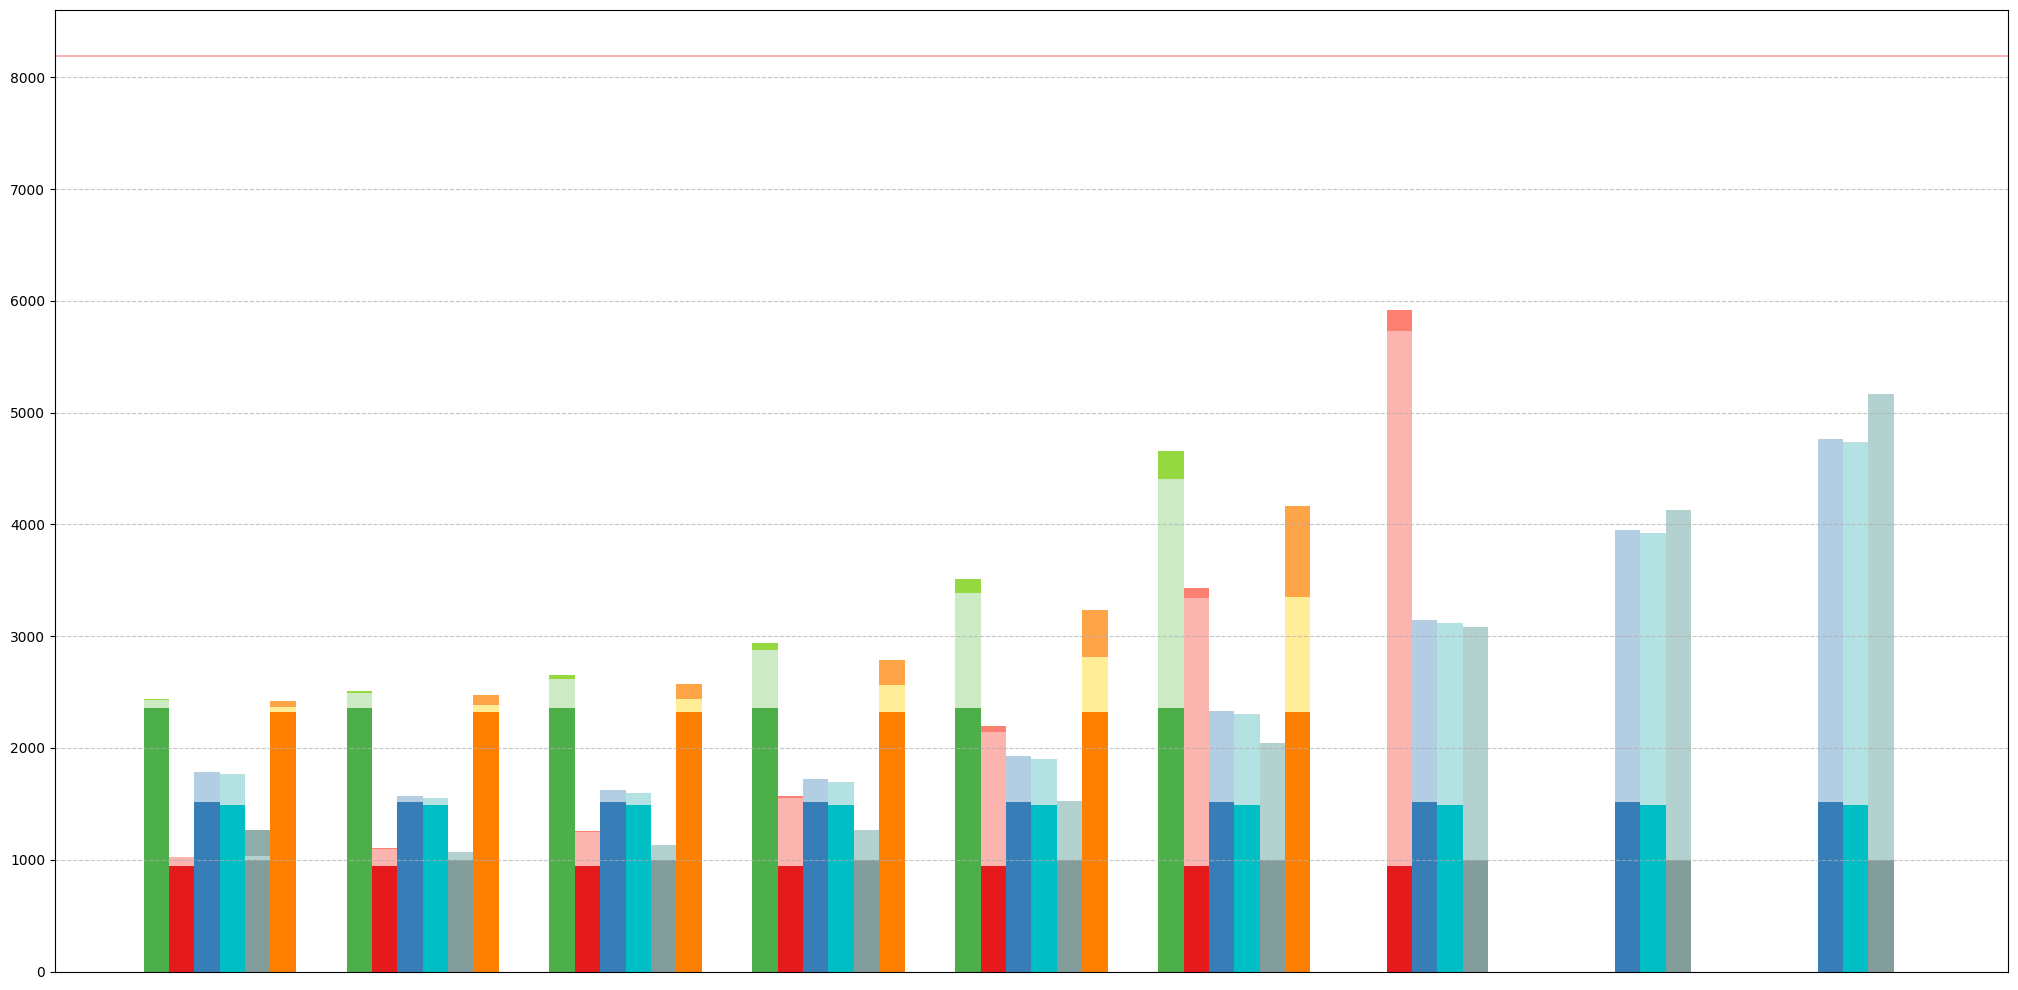

In [9]:
# Create a detailed stacked bar visualization for six models: Qwen 0.5B, Mamba-790m, Zamba2, Llama3-2B, Mamba2, Falcon
plt.figure(figsize=(26, 10))

seq_lengths = sorted(list(set(qwen_df['seq_len'].tolist() + mamba_df['seq_len'].tolist() + zamba2_df['seq_len'].tolist())))
x = np.arange(len(seq_lengths))
# Compose the union of all sequence lengths
all_seq_lengths = sorted(list(set(
    qwen_df['seq_len'].tolist() +
    mamba_df['seq_len'].tolist() +
    zamba2_df['seq_len'].tolist() +
    llama3_2_df['seq_len'].tolist() +
    mamba2_df['seq_len'].tolist() +
    falcon_h1_df['seq_len'].tolist()  # NEW: Add Falcon
)))

x = np.arange(len(all_seq_lengths)) * 1.2  # Increase spacing between ticks
bar_width = 0.15  # Make bars thinner

# Prepare data for plotting
qwen_data = get_model_data(qwen_df, seq_lengths)
mamba_data = get_model_data(mamba_df, seq_lengths)
zamba2_data = get_model_data(zamba2_df, seq_lengths)
llama3_2_data = get_model_data(llama3_2_df, seq_lengths)
mamba2_data = get_model_data(mamba2_df, seq_lengths)
falcon_data = get_model_data(falcon_h1_df, seq_lengths)  # NEW: Add Falcon

# Prepare data for plotting
qwen_arrays = create_arrays(qwen_data, all_seq_lengths)
mamba_arrays = create_arrays(mamba_data, all_seq_lengths)
zamba2_arrays = create_arrays(zamba2_data, all_seq_lengths)
llama3_2_arrays = create_arrays(llama3_2_data, all_seq_lengths)
mamba2_arrays = create_arrays(mamba2_data, all_seq_lengths)
falcon_arrays = create_arrays(falcon_data, all_seq_lengths)  # NEW: Add Falcon

# Define color schemes
qwen_colors = {'model': '#E41A1C', 'activation': '#FBB4AE', 'kv': '#FB8072', 'reserved': 'red'}
mamba_colors = {'model': '#377EB8', 'activation': '#B3CDE3', 'kv': '#6BAED6', 'reserved': 'blue'}
zamba2_colors = {'model': '#FF7F00', 'activation': '#FFED97', 'kv': '#FFA347', 'reserved': 'orange'}
llama3_2_colors = {'model': '#4DAF4A', 'activation': '#CCEBC5', 'kv': '#95D840', 'reserved': 'green'}
mamba2_colors = {'model': '#00BFC4', 'activation': '#B4E2E2', 'kv': '#1DE9B6', 'reserved': '#008080'}
falcon_colors = {'model': '#829D9A', 'activation': "#B3D1CE", 'kv': "#8EACA8", 'reserved': "#738886"}  # NEW: Add Falcon

# Plot stacked bars for each model with offsets - adjusted for six models
plt.bar(x - 2.5*bar_width, llama3_2_arrays['model_sizes'], bar_width, label='Llama3-2B: Model Size', color=llama3_2_colors['model'])
plt.bar(x - 2.5*bar_width, llama3_2_arrays['activations'], bar_width, bottom=llama3_2_arrays['model_sizes'], color=llama3_2_colors['activation'])
plt.bar(x - 2.5*bar_width, llama3_2_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(llama3_2_arrays['model_sizes'], llama3_2_arrays['activations'])], color=llama3_2_colors['kv'])

plt.bar(x - 1.5*bar_width, qwen_arrays['model_sizes'], bar_width, label='Qwen 0.5B: Model Size', color=qwen_colors['model'])
plt.bar(x - 1.5*bar_width, qwen_arrays['activations'], bar_width, bottom=qwen_arrays['model_sizes'], color=qwen_colors['activation'])
plt.bar(x - 1.5*bar_width, qwen_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(qwen_arrays['model_sizes'], qwen_arrays['activations'])], color=qwen_colors['kv'])

plt.bar(x - 0.5*bar_width, mamba_arrays['model_sizes'], bar_width, label='Mamba-790m: Model Size', color=mamba_colors['model'])
plt.bar(x - 0.5*bar_width, mamba_arrays['activations'], bar_width, bottom=mamba_arrays['model_sizes'], color=mamba_colors['activation'])
plt.bar(x - 0.5*bar_width, mamba_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(mamba_arrays['model_sizes'], mamba_arrays['activations'])], color=mamba_colors['kv'])

plt.bar(x + 0.5*bar_width, mamba2_arrays['model_sizes'], bar_width, label='Mamba2: Model Size', color=mamba2_colors['model'])
plt.bar(x + 0.5*bar_width, mamba2_arrays['activations'], bar_width, bottom=mamba2_arrays['model_sizes'], color=mamba2_colors['activation'])
plt.bar(x + 0.5*bar_width, mamba2_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(mamba2_arrays['model_sizes'], mamba2_arrays['activations'])], color=mamba2_colors['kv'])

plt.bar(x + 1.5*bar_width, falcon_arrays['model_sizes'], bar_width, label='Falcon: Model Size', color=falcon_colors['model'])  # NEW: Add Falcon
plt.bar(x + 1.5*bar_width, falcon_arrays['activations'], bar_width, bottom=falcon_arrays['model_sizes'], color=falcon_colors['activation'])  # NEW: Add Falcon
plt.bar(x + 1.5*bar_width, falcon_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(falcon_arrays['model_sizes'], falcon_arrays['activations'])], color=falcon_colors['kv'])  # NEW: Add Falcon

plt.bar(x + 2.5*bar_width, zamba2_arrays['model_sizes'], bar_width, label='Zamba2: Model Size', color=zamba2_colors['model'])
plt.bar(x + 2.5*bar_width, zamba2_arrays['activations'], bar_width, bottom=zamba2_arrays['model_sizes'], color=zamba2_colors['activation'])
plt.bar(x + 2.5*bar_width, zamba2_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(zamba2_arrays['model_sizes'], zamba2_arrays['activations'])], color=zamba2_colors['kv'])

# # Plot reserved memory lines - adjusted to match new bar positions
# plot_reserved_memory(x, llama3_2_arrays, all_seq_lengths, -2.5*bar_width, llama3_2_colors['reserved'], 'Llama3-2B: Reserved Memory')
# plot_reserved_memory(x, qwen_arrays, all_seq_lengths, -1.5*bar_width, qwen_colors['reserved'], 'Qwen 0.5B: Reserved Memory')
# plot_reserved_memory(x, mamba_arrays, all_seq_lengths, -0.5*bar_width, mamba_colors['reserved'], 'Mamba-790m: Reserved Memory')
# plot_reserved_memory(x, mamba2_arrays, all_seq_lengths, 0.5*bar_width, mamba2_colors['reserved'], 'Mamba2: Reserved Memory')
# plot_reserved_memory(x, falcon_arrays, all_seq_lengths, 1.5*bar_width, falcon_colors['reserved'], 'Falcon: Reserved Memory')  # NEW: Add Falcon
# plot_reserved_memory(x, zamba2_arrays, all_seq_lengths, 2.5*bar_width, zamba2_colors['reserved'], 'Zamba2: Reserved Memory')

# Add a horizontal line at 24GB to indicate GPU memory limit
plt.axhline(y=8192, color='red', linestyle='-', alpha=0.3, label='24GB GPU Memory Limit')

# Remove ticks
plt.xticks([])
# plt.yticks([])

plt.grid(axis='y', linestyle='--', alpha=0.7)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

model_size_legend = [
    Patch(facecolor=qwen_colors['model'], label='Qwen 0.5B: Model Size'),
    Patch(facecolor=mamba_colors['model'], label='Mamba-790m: Model Size'),
    Patch(facecolor=zamba2_colors['model'], label='Zamba2: Model Size'),
    Patch(facecolor=llama3_2_colors['model'], label='Llama3-2B: Model Size'),
    Patch(facecolor=mamba2_colors['model'], label='Mamba2: Model Size'),
    Patch(facecolor=falcon_colors['model'], label='Falcon: Model Size')  # NEW: Add Falcon
]

activation_legend = [
    Patch(facecolor=qwen_colors['activation'], label='Qwen 0.5B: Activation'),
    Patch(facecolor=mamba_colors['activation'], label='Mamba-790m: Activation'),
    Patch(facecolor=zamba2_colors['activation'], label='Zamba2: Activation'),
    Patch(facecolor=llama3_2_colors['activation'], label='Llama3-2B: Activation'),
    Patch(facecolor=mamba2_colors['activation'], label='Mamba2: Activation'),
    Patch(facecolor=falcon_colors['activation'], label='Falcon: Activation')  # NEW: Add Falcon
]

kv_cache_legend = [
    Patch(facecolor=qwen_colors['kv'], label='Qwen 0.5B: KV Cache'),
    Patch(facecolor=mamba_colors['kv'], label='Mamba-790m: KV Cache'),
    Patch(facecolor=zamba2_colors['kv'], label='Zamba2: KV Cache'),
    Patch(facecolor=llama3_2_colors['kv'], label='Llama3-2B: KV Cache'),
    Patch(facecolor=mamba2_colors['kv'], label='Mamba2: KV Cache'),
    Patch(facecolor=falcon_colors['kv'], label='Falcon: KV Cache')  # NEW: Add Falcon
]

reserved_legend = [
    Line2D([0], [0], color=qwen_colors['reserved'], linestyle='--', marker='o', label='Qwen 0.5B: Reserved'),
    Line2D([0], [0], color=mamba_colors['reserved'], linestyle='--', marker='o', label='Mamba-790m: Reserved'),
    Line2D([0], [0], color=zamba2_colors['reserved'], linestyle='--', marker='o', label='Zamba2: Reserved'),
    Line2D([0], [0], color=llama3_2_colors['reserved'], linestyle='--', marker='o', label='Llama3-2B: Reserved'),
    Line2D([0], [0], color=mamba2_colors['reserved'], linestyle='--', marker='o', label='Mamba2: Reserved'),
    Line2D([0], [0], color=falcon_colors['reserved'], linestyle='--', marker='o', label='Falcon: Reserved')  # NEW: Add Falcon
]

# Assuming legends are combined elsewhere in the notebook, but since not shown, no change here

plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()


## Publication Figure

Clean version of the same plot — y-axis tick labels removed for use as a paper figure. The output is saved to `memory_footprint_jetson_ispass.png` at 300 DPI.

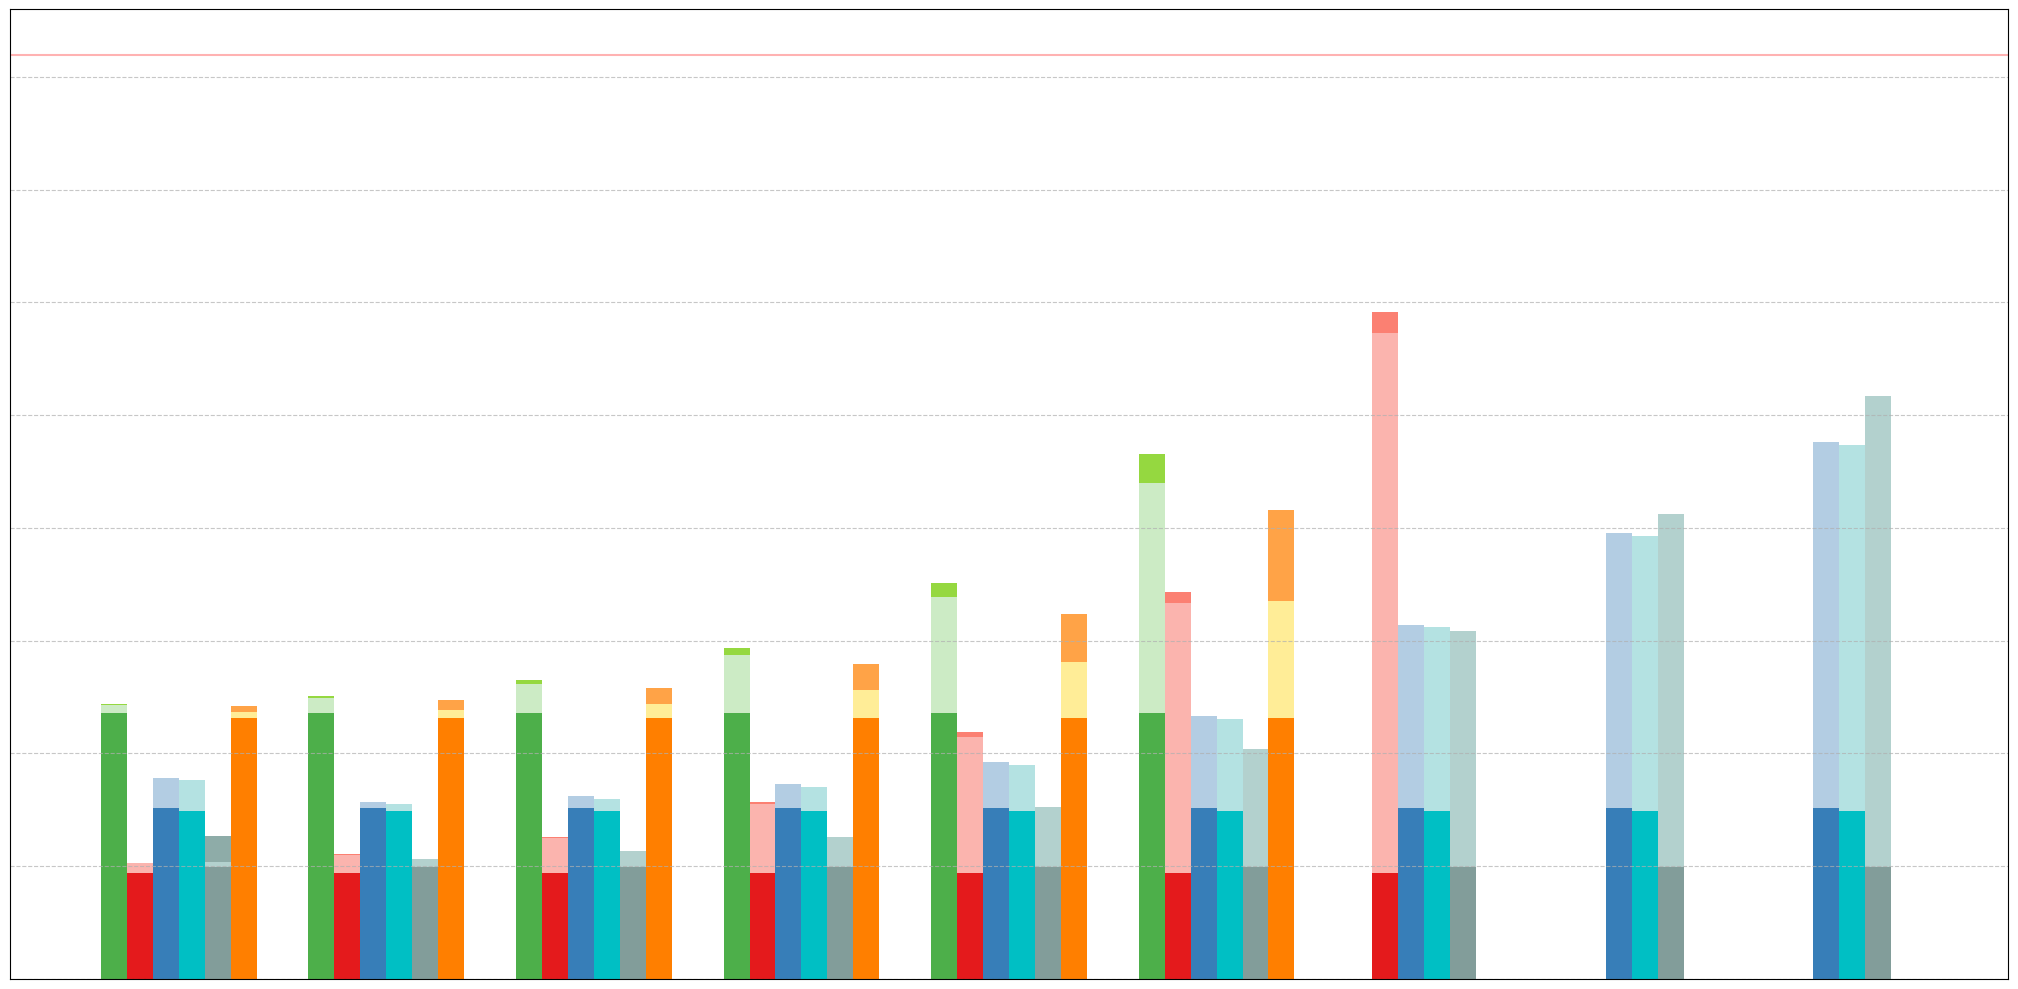

In [10]:
# Create a detailed stacked bar visualization for six models: Qwen 0.5B, Mamba-790m, Zamba2, Llama3-2B, Mamba2, Falcon
plt.figure(figsize=(26, 10))

# Compose the union of all sequence lengths
all_seq_lengths = sorted(list(set(
    qwen_df['seq_len'].tolist() +
    mamba_df['seq_len'].tolist() +
    zamba2_df['seq_len'].tolist() +
    llama3_2_df['seq_len'].tolist() +
    mamba2_df['seq_len'].tolist() +
    falcon_h1_df['seq_len'].tolist()  # NEW: Add Falcon
)))

x = np.arange(len(all_seq_lengths)) * 1.2  # Increase spacing between ticks
bar_width = 0.15  # Make bars thinner

# Prepare data for plotting
qwen_data = get_model_data(qwen_df, seq_lengths)
mamba_data = get_model_data(mamba_df, seq_lengths)
zamba2_data = get_model_data(zamba2_df, seq_lengths)
llama3_2_data = get_model_data(llama3_2_df, seq_lengths)
mamba2_data = get_model_data(mamba2_df, seq_lengths)
falcon_data = get_model_data(falcon_h1_df, seq_lengths)  # NEW: Add Falcon

# Prepare data for plotting
qwen_arrays = create_arrays(qwen_data, all_seq_lengths)
mamba_arrays = create_arrays(mamba_data, all_seq_lengths)
zamba2_arrays = create_arrays(zamba2_data, all_seq_lengths)
llama3_2_arrays = create_arrays(llama3_2_data, all_seq_lengths)
mamba2_arrays = create_arrays(mamba2_data, all_seq_lengths)
falcon_arrays = create_arrays(falcon_data, all_seq_lengths)  # NEW: Add Falcon

# Define color schemes
qwen_colors = {'model': '#E41A1C', 'activation': '#FBB4AE', 'kv': '#FB8072', 'reserved': 'red'}
mamba_colors = {'model': '#377EB8', 'activation': '#B3CDE3', 'kv': '#6BAED6', 'reserved': 'blue'}
zamba2_colors = {'model': '#FF7F00', 'activation': '#FFED97', 'kv': '#FFA347', 'reserved': 'orange'}
llama3_2_colors = {'model': '#4DAF4A', 'activation': '#CCEBC5', 'kv': '#95D840', 'reserved': 'green'}
mamba2_colors = {'model': '#00BFC4', 'activation': '#B4E2E2', 'kv': '#1DE9B6', 'reserved': '#008080'}
falcon_colors = {'model': '#829D9A', 'activation': "#B3D1CE", 'kv': "#8EACA8", 'reserved': "#738886"}  # NEW: Add Falcon

# Plot stacked bars for each model with offsets - adjusted for six models
plt.bar(x - 2.5*bar_width, llama3_2_arrays['model_sizes'], bar_width, label='Llama3-2B: Model Size', color=llama3_2_colors['model'])
plt.bar(x - 2.5*bar_width, llama3_2_arrays['activations'], bar_width, bottom=llama3_2_arrays['model_sizes'], color=llama3_2_colors['activation'])
plt.bar(x - 2.5*bar_width, llama3_2_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(llama3_2_arrays['model_sizes'], llama3_2_arrays['activations'])], color=llama3_2_colors['kv'])

plt.bar(x - 1.5*bar_width, qwen_arrays['model_sizes'], bar_width, label='Qwen 0.5B: Model Size', color=qwen_colors['model'])
plt.bar(x - 1.5*bar_width, qwen_arrays['activations'], bar_width, bottom=qwen_arrays['model_sizes'], color=qwen_colors['activation'])
plt.bar(x - 1.5*bar_width, qwen_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(qwen_arrays['model_sizes'], qwen_arrays['activations'])], color=qwen_colors['kv'])

plt.bar(x - 0.5*bar_width, mamba_arrays['model_sizes'], bar_width, label='Mamba-790m: Model Size', color=mamba_colors['model'])
plt.bar(x - 0.5*bar_width, mamba_arrays['activations'], bar_width, bottom=mamba_arrays['model_sizes'], color=mamba_colors['activation'])
plt.bar(x - 0.5*bar_width, mamba_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(mamba_arrays['model_sizes'], mamba_arrays['activations'])], color=mamba_colors['kv'])

plt.bar(x + 0.5*bar_width, mamba2_arrays['model_sizes'], bar_width, label='Mamba2: Model Size', color=mamba2_colors['model'])
plt.bar(x + 0.5*bar_width, mamba2_arrays['activations'], bar_width, bottom=mamba2_arrays['model_sizes'], color=mamba2_colors['activation'])
plt.bar(x + 0.5*bar_width, mamba2_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(mamba2_arrays['model_sizes'], mamba2_arrays['activations'])], color=mamba2_colors['kv'])

plt.bar(x + 1.5*bar_width, falcon_arrays['model_sizes'], bar_width, label='Falcon: Model Size', color=falcon_colors['model'])  # NEW: Add Falcon
plt.bar(x + 1.5*bar_width, falcon_arrays['activations'], bar_width, bottom=falcon_arrays['model_sizes'], color=falcon_colors['activation'])  # NEW: Add Falcon
plt.bar(x + 1.5*bar_width, falcon_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(falcon_arrays['model_sizes'], falcon_arrays['activations'])], color=falcon_colors['kv'])  # NEW: Add Falcon

plt.bar(x + 2.5*bar_width, zamba2_arrays['model_sizes'], bar_width, label='Zamba2: Model Size', color=zamba2_colors['model'])
plt.bar(x + 2.5*bar_width, zamba2_arrays['activations'], bar_width, bottom=zamba2_arrays['model_sizes'], color=zamba2_colors['activation'])
plt.bar(x + 2.5*bar_width, zamba2_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(zamba2_arrays['model_sizes'], zamba2_arrays['activations'])], color=zamba2_colors['kv'])

# # Plot reserved memory lines - adjusted to match new bar positions
# plot_reserved_memory(x, llama3_2_arrays, all_seq_lengths, -2.5*bar_width, llama3_2_colors['reserved'], 'Llama3-2B: Reserved Memory')
# plot_reserved_memory(x, qwen_arrays, all_seq_lengths, -1.5*bar_width, qwen_colors['reserved'], 'Qwen 0.5B: Reserved Memory')
# plot_reserved_memory(x, mamba_arrays, all_seq_lengths, -0.5*bar_width, mamba_colors['reserved'], 'Mamba-790m: Reserved Memory')
# plot_reserved_memory(x, mamba2_arrays, all_seq_lengths, 0.5*bar_width, mamba2_colors['reserved'], 'Mamba2: Reserved Memory')
# plot_reserved_memory(x, falcon_arrays, all_seq_lengths, 1.5*bar_width, falcon_colors['reserved'], 'Falcon: Reserved Memory')  # NEW: Add Falcon
# plot_reserved_memory(x, zamba2_arrays, all_seq_lengths, 2.5*bar_width, zamba2_colors['reserved'], 'Zamba2: Reserved Memory')

# Add a horizontal line at 24GB to indicate GPU memory limit
plt.axhline(y=8192, color='red', linestyle='-', alpha=0.3, label='24GB GPU Memory Limit')

# Remove ticks
plt.xticks([])
# plt.yticks([])
plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)


plt.grid(axis='y', linestyle='--', alpha=0.7)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

model_size_legend = [
    Patch(facecolor=qwen_colors['model'], label='Qwen 0.5B: Model Size'),
    Patch(facecolor=mamba_colors['model'], label='Mamba-790m: Model Size'),
    Patch(facecolor=zamba2_colors['model'], label='Zamba2: Model Size'),
    Patch(facecolor=llama3_2_colors['model'], label='Llama3-2B: Model Size'),
    Patch(facecolor=mamba2_colors['model'], label='Mamba2: Model Size'),
    Patch(facecolor=falcon_colors['model'], label='Falcon: Model Size')  # NEW: Add Falcon
]

activation_legend = [
    Patch(facecolor=qwen_colors['activation'], label='Qwen 0.5B: Activation'),
    Patch(facecolor=mamba_colors['activation'], label='Mamba-790m: Activation'),
    Patch(facecolor=zamba2_colors['activation'], label='Zamba2: Activation'),
    Patch(facecolor=llama3_2_colors['activation'], label='Llama3-2B: Activation'),
    Patch(facecolor=mamba2_colors['activation'], label='Mamba2: Activation'),
    Patch(facecolor=falcon_colors['activation'], label='Falcon: Activation')  # NEW: Add Falcon
]

kv_cache_legend = [
    Patch(facecolor=qwen_colors['kv'], label='Qwen 0.5B: KV Cache'),
    Patch(facecolor=mamba_colors['kv'], label='Mamba-790m: KV Cache'),
    Patch(facecolor=zamba2_colors['kv'], label='Zamba2: KV Cache'),
    Patch(facecolor=llama3_2_colors['kv'], label='Llama3-2B: KV Cache'),
    Patch(facecolor=mamba2_colors['kv'], label='Mamba2: KV Cache'),
    Patch(facecolor=falcon_colors['kv'], label='Falcon: KV Cache')  # NEW: Add Falcon
]

reserved_legend = [
    Line2D([0], [0], color=qwen_colors['reserved'], linestyle='--', marker='o', label='Qwen 0.5B: Reserved'),
    Line2D([0], [0], color=mamba_colors['reserved'], linestyle='--', marker='o', label='Mamba-790m: Reserved'),
    Line2D([0], [0], color=zamba2_colors['reserved'], linestyle='--', marker='o', label='Zamba2: Reserved'),
    Line2D([0], [0], color=llama3_2_colors['reserved'], linestyle='--', marker='o', label='Llama3-2B: Reserved'),
    Line2D([0], [0], color=mamba2_colors['reserved'], linestyle='--', marker='o', label='Mamba2: Reserved'),
    Line2D([0], [0], color=falcon_colors['reserved'], linestyle='--', marker='o', label='Falcon: Reserved')  # NEW: Add Falcon
]

# Assuming legends are combined elsewhere in the notebook, but since not shown, no change here

plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.savefig('memory_footprint_jetson_ispass.png', dpi=300, bbox_inches='tight')
plt.show()
